# COPER 1-NODE: sweep `latent_dim` (MIMIC mortality)

Trains **COPER without `--second-node`** (single ODE before the Perceiver) for several values of `--latent-dim`, using the same protocol as `compare_mortality_mimic3.ipynb`.

- Each run uses its own `--results-dir` subdirectory so checkpoints do not overwrite each other (checkpoint names do not include `latent-dim`).
- After the sweep, we plot **Test-OG AUROC** (and optionally AUPRC) vs **latent dimension** and vs **total parameter count** to compare capacity vs performance.

**Requirements:** MIMIC mortality pickle, `paths.json` patch (below), GPU recommended. Reduce `LATENT_DIMS` or `NITERS` for a quick smoke test.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

BENCH = Path("/home/charlesv/Desktop/StatisitcalGenetics/code/COPER").resolve()
if str(BENCH) not in sys.path:
    sys.path.insert(0, str(BENCH))

from utils.benchmark_utils import patch_paths_json, restore_paths_json, run_one
from utils.coper_param_count import count_coper_params_mimic

In [2]:
# ---- Paths ----
ROOT = Path("/home/charlesv/Desktop/StatisitcalGenetics")
REPO = ROOT / "code" / "COPER"
assert REPO.is_dir(), REPO

MORTALITY_PICKLE = ROOT / "MIMIC" / "mimic3-benchmarks" / "data" / "mortality_for_coper.data"
assert MORTALITY_PICKLE.is_file(), MORTALITY_PICKLE

SWEEP_ROOT = REPO / "results" / "latent_dim_sweep"
TABLES = REPO / "results" / "tables"
TABLES.mkdir(parents=True, exist_ok=True)

PYTHON = str(REPO / ".venv-coper" / "bin" / "python")
if not Path(PYTHON).is_file():
    PYTHON = sys.executable

# ---- Sweep settings (1-NODE only; never pass --second-node) ----
LATENT_DIMS = [10, 20, 32, 48, 64, 96, 128] # according to paper best latent dim for mimic mortality was 64
SEED = 1
DROP = 0.5
FOLD = -1
NITERS = 1  # increase (e.g. 10–120) for a serious comparison
BATCH_SIZE = 64
PATIENCE = 10

# Shared CLI args; `--latent-dim` and `--results-dir` are added inside the loop.
SHARED = [
    "--model-type", "COPER",
    "--dataset", "mimic",
    "--cont-in",
    "--self-per-cross-attn", "1",
    "--latent-heads", "2",
    "--cross-heads", "1",
    "--cross-dim-head", "128",
    "--latent-dim-head", "128",
    "--units", "128",
    "--ode-dropout", "0.5",
    "--att-dropout", "0.5",
    "--ff-dropout", "0.5",
    "--num-latents", "48",
    "--batch-size", str(BATCH_SIZE),
    "--patience", str(PATIENCE),
    "--niters", str(NITERS),
    "--fold", str(FOLD),
]

In [3]:
rows: list[dict] = []
original = patch_paths_json(REPO, MORTALITY_PICKLE)
try:
    SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
    for ld in LATENT_DIMS:
        rd = SWEEP_ROOT / f"ld{ld}"
        rd.mkdir(parents=True, exist_ok=True)
        shared_run = SHARED + [
            "--results-dir",
            str(rd.resolve()),
            "--latent-dim",
            str(ld),
        ]
        print(f"=== latent_dim={ld} | --results-dir={rd} ===")
        row = run_one(
            arch_id=f"coper_1node_ld{ld}",
            arch_label=f"1-NODE COPER, latent_dim={ld}",
            extra_args=[],
            seed=SEED,
            drop=DROP,
            shared_args=shared_run,
            repo=REPO,
            results_root=rd,
            fold=FOLD,
            python_executable=PYTHON,
        )
        row["latent_dim"] = ld
        rows.append(row)
        print(
            f"  rc={row['return_code']} Test-OG AUROC={row['test_og_auroc']:.4f} "
            f"runtime={row['runtime_sec']:.1f}s ckpt_exists={row['ckpt_exists']}"
        )
finally:
    restore_paths_json(REPO, original)

=== latent_dim=10 | --results-dir=/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/latent_dim_sweep/ld10 ===
  rc=0 Test-OG AUROC=0.6694 runtime=181.1s ckpt_exists=True
=== latent_dim=20 | --results-dir=/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/latent_dim_sweep/ld20 ===
  rc=0 Test-OG AUROC=0.7056 runtime=172.9s ckpt_exists=True
=== latent_dim=32 | --results-dir=/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/latent_dim_sweep/ld32 ===
  rc=0 Test-OG AUROC=0.7429 runtime=177.7s ckpt_exists=True
=== latent_dim=48 | --results-dir=/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/latent_dim_sweep/ld48 ===
  rc=0 Test-OG AUROC=0.7662 runtime=178.8s ckpt_exists=True
=== latent_dim=64 | --results-dir=/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/latent_dim_sweep/ld64 ===
  rc=0 Test-OG AUROC=0.7779 runtime=175.1s ckpt_exists=True
=== latent_dim=96 | --results-dir=/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/re

Saved /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/tables/latent_dim_sweep.csv


,latent_dim,n_params,return_code,test_og_auroc,test_og_auprc,test_g_auroc,runtime_sec
0,10,84807,0,0.6694,0.2086,0.6691,181.079569
1,20,103117,0,0.7056,0.2295,0.7069,172.852314
2,32,129313,0,0.7429,0.2824,0.7414,177.691527
3,48,171409,0,0.7662,0.3248,0.7643,178.825119
4,64,221697,0,0.7779,0.3306,0.7765,175.050151
5,96,346849,0,0.7505,0.3055,0.7473,183.580881
6,128,504769,0,0.7789,0.3372,0.7765,181.466504


Saved /home/charlesv/Desktop/StatisitcalGenetics/pictures/latent_dim_mortality_table.png
Saved /home/charlesv/Desktop/StatisitcalGenetics/pictures/latent_dim_mortality_curves.png


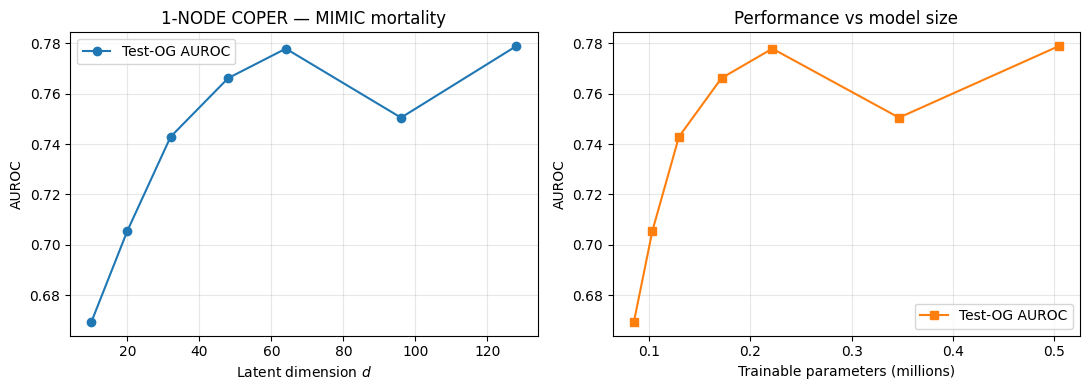

Best Test-OG AUROC:
 latent_dim          128.0000
n_params         504769.0000
test_og_auroc         0.7789
test_og_auprc         0.3372
Name: 6, dtype: float64


In [5]:
df = pd.DataFrame(rows)
df["n_params"] = [
    count_coper_params_mimic(int(ld), second_node=False) for ld in df["latent_dim"]
]

out_csv = TABLES / "latent_dim_sweep.csv"
df_out = df.drop(columns=["raw_tail"], errors="ignore")
df_out.to_csv(out_csv, index=False)
print("Saved", out_csv)
display(df_out[["latent_dim", "n_params", "return_code", "test_og_auroc", "test_og_auprc", "test_g_auroc", "runtime_sec"]])

PICTURES = ROOT / "pictures"
PICTURES.mkdir(parents=True, exist_ok=True)

# Table image for Beamer (reports/slides_presentation_s1/slides1_vielzeuf.tex)
_cols = ["latent_dim", "n_params", "test_og_auroc", "test_og_auprc", "test_g_auroc"]
_hdr = ["$d$", "Params", "Test-OG AUROC", "Test-OG AUPRC", "Test-G AUROC"]
_cell_text = []
for _, r in df_out[_cols].iterrows():
    _cell_text.append(
        [
            str(int(r["latent_dim"])),
            f"{int(r['n_params']):,}",
            f"{r['test_og_auroc']:.4f}",
            f"{r['test_og_auprc']:.4f}",
            f"{r['test_g_auroc']:.4f}",
        ]
    )
_h = max(2.0, 0.35 * len(_cell_text))
fig_tbl, ax_tbl = plt.subplots(figsize=(11, _h))
ax_tbl.axis("off")
_tbl = ax_tbl.table(
    cellText=_cell_text,
    colLabels=_hdr,
    loc="center",
    cellLoc="center",
)
_tbl.auto_set_font_size(False)
_tbl.set_fontsize(8)
_tbl.scale(1.0, 1.35)
fig_tbl.tight_layout()
_p_tbl = PICTURES / "latent_dim_mortality_table.png"
fig_tbl.savefig(_p_tbl, dpi=150, bbox_inches="tight")
plt.close(fig_tbl)
print("Saved", _p_tbl)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax0, ax1 = axes

ax0.plot(df["latent_dim"], df["test_og_auroc"], "o-", label="Test-OG AUROC")
ax0.set_xlabel(r"Latent dimension $d$")
ax0.set_ylabel("AUROC")
ax0.set_title("1-NODE COPER — MIMIC mortality")
ax0.grid(True, alpha=0.3)
ax0.legend()

ax1.plot(df["n_params"] / 1e6, df["test_og_auroc"], "s-", color="C1", label="Test-OG AUROC")
ax1.set_xlabel("Trainable parameters (millions)")
ax1.set_ylabel("AUROC")
ax1.set_title("Performance vs model size")
ax1.grid(True, alpha=0.3)
ax1.legend()

plt.tight_layout()
_p_curves = PICTURES / "latent_dim_mortality_curves.png"
fig.savefig(_p_curves, dpi=150, bbox_inches="tight")
print("Saved", _p_curves)
plt.show()

valid = df["test_og_auroc"].notna()
if valid.any():
    ib = df.loc[valid, "test_og_auroc"].idxmax()
    print("Best Test-OG AUROC:\n", df.loc[ib, ["latent_dim", "n_params", "test_og_auroc", "test_og_auprc"]])